# Component 1: CPS ASEC — Retirement Plan Access and Participation


## Plan of attack
- Set up reproducible paths and output folders.
- Identify CPS ASEC variables for access/participation, weights, and sample restrictions.
- Build a clean analytic sample and document coding decisions.
- Produce annual estimates, figures, and tables for the write-up.


In [ ]:
# Import the packages we need for this notebook. We import some standard data science packages like pandas and matplotlib, as well as some utilities for handling file paths. 
# We also import the project paths and directory setup functions from our local `project_paths` module to ensure we have access to the correct directories for data and output.
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add the project `code/` directory to sys.path so local modules import cleanly.
cwd = Path.cwd().resolve()
if (cwd / 'code').exists():
    code_dir = cwd / 'code'
elif cwd.name == 'code':
    code_dir = cwd
elif cwd.name == 'build' and cwd.parent.name == 'code':
    code_dir = cwd.parent
else:
    code_dir = cwd

if str(code_dir) not in sys.path:
    sys.path.insert(0, str(code_dir))

from project_paths import (
    ROOT,
    GIVEN_DIR,
    CODE_DIR,
    NOTEBOOK_BUILD_DIR,
    DATA_DIR,
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    OUTPUT_DIR,
    FIGURES_DIR,
    TABLES_DIR,
    WRITEUP_DIR,
    GUIDES_DIR,
    C1_WRITEUP_TEX,
    C2_WRITEUP_TEX,
    C3_PITCH_TEX,
    BIB_FILE,
    ensure_project_dirs,
    print_project_paths,
)

ensure_project_dirs()
print_project_paths()


Project paths:
- ROOT: .
- GIVEN_DIR: ./_given
- CODE_DIR: ./code
- NOTEBOOK_BUILD_DIR: ./code/build
- DATA_DIR: ./data
- RAW_DATA_DIR: ./data/raw
- PROCESSED_DATA_DIR: ./data/processed
- OUTPUT_DIR: ./output
- FIGURES_DIR: ./output/figures
- TABLES_DIR: ./output/tables
- WRITEUP_DIR: ./writeup
- GUIDES_DIR: ./writeup/_guides
- C1_WRITEUP_TEX: ./writeup/c1/c1_adlt_writeup.tex
- C2_WRITEUP_TEX: ./writeup/c2/c2_adlt_summary.tex
- C3_PITCH_TEX: ./writeup/c3/c3_adlt_pitch.tex
- BIB_FILE: ./writeup/brookings.bib


## Variable crosswalk: CPS ASEC variables

Before constructing the analytic sample, I need to identify the exact CPS ASEC
variables that correspond to the concepts required for this task.

I am **assuming** that the analysis requires variables for:

- Age
- Employment status
- Class of worker (to restrict to private-sector workers)
- Retirement plan access
- Retirement plan participation
- Survey weights
- Survey year

The next step is to identify these variables and confirm that they are
consistent across the 2010–2024 CPS ASEC files.

In [17]:
crosswalk = pd.DataFrame({
    "concept": [
        "age",
        "employment status",
        "class of worker",
        "retirement plan access",
        "retirement plan participation",
        "survey weight",
        "survey year"
    ],
    "variable_name": "",
    "description": "",
    "years_available": "",
    "notes": ""
})

crosswalk

,concept,variable_name,description,years_available,notes
0,age,,,,
1,employment status,,,,
2,class of worker,,,,
3,retirement plan access,,,,
4,retirement plan participation,,,,
5,survey weight,,,,
6,survey year,,,,


### NOTE: CPS ASEC 2015 redesign

The CPS ASEC survey was redesigned in 2015, which may affect the
comparability of certain variables across years.

Before constructing the final time series, I will verify whether the
retirement plan access and participation questions changed wording
or coding after 2015. Please see the documentation at ./data/!documentation


## Load CPS ASEC extract and begin sample construction

The IPUMS-CPS ASEC extract has been downloaded locally. The next steps are:

1. Load the person-level pooled ASEC file.
2. Inspect variable names, missing values, and coding for the key variables:
   - YEAR
   - AGE
   - EMPSTAT
   - CLASSWKR
   - ASECWT
   - UH_PENPLAN_A1
   - UH_PENSINCL_A1
3. Restrict the sample to private-sector workers ages 20–64.
4. Construct annual measures of retirement plan access and participation.
5. Produce the required figure and table.

In [18]:
import pandas as pd
import numpy as np
from pathlib import Path

# Locate repo root (assumes the notebook lives inside the repo)
ROOT = Path.cwd().resolve()
if not ((ROOT / 'data').exists() and (ROOT / 'code').exists()):
    for parent in ROOT.parents:
        if (parent / 'data').exists() and (parent / 'code').exists():
            ROOT = parent
            break

raw_fp = ROOT / 'data' / 'raw' / 'cps_00001.csv.gz'
if not raw_fp.exists():
    raise FileNotFoundError(
        'Raw CPS ASEC extract not found. Place it in data/raw/ or update raw_fp.'
    )

# Load data
df = pd.read_csv(raw_fp, compression='gzip', low_memory=False)

print(df.shape)
print(df.columns.tolist())
df.head()


(2713615, 61)
['YEAR', 'SERIAL', 'MONTH', 'CPSID', 'ASECFLAG', 'HFLAG', 'ASECWTH', 'REGION', 'STATEFIP', 'COUNTY', 'METFIPS', 'METRO', 'CBSASZ', 'HHINCOME', 'PERNUM', 'CPSIDP', 'CPSIDV', 'ASECWT', 'AGE', 'SEX', 'RACE', 'MARST', 'ASIAN', 'VETSTAT', 'FAMSIZE', 'NCHILD', 'NCHLT5', 'BPL', 'CITIZEN', 'NATIVITY', 'HISPAN', 'EMPSTAT', 'LABFORCE', 'OCC', 'IND', 'CLASSWKR', 'UHRSWORKT', 'AHRSWORKT', 'WKSTAT', 'EDUC', 'CLASSWLY', 'WKSWORK1', 'PENSION', 'FIRMSIZE', 'FTOTVAL', 'INCTOT', 'INCTOT_CPIU_2010', 'INCWAGE', 'INCWAGE_CPIU_2010', 'INCBUS', 'INCFARM', 'INCWELFR', 'INCDISAB', 'POVERTY', 'MIGRATE5', 'DISABWRK', 'UNION', 'EARNWEEK', 'EARNWEEK_CPIU_2010', 'UH_PENPLAN_A1', 'UH_PENSINCL_A1']


,YEAR,SERIAL,MONTH,CPSID,ASECFLAG,HFLAG,ASECWTH,REGION,STATEFIP,COUNTY,...,INCWELFR,INCDISAB,POVERTY,MIGRATE5,DISABWRK,UNION,EARNWEEK,EARNWEEK_CPIU_2010,UH_PENPLAN_A1,UH_PENSINCL_A1
0,2010,1,3,20091200101400,1,NaN,485.99,11,23,0,...,0,0,22,NaN,2,0,9999.99,99999999.99,0,0
1,2010,2,3,20091201328700,1,NaN,531.71,11,23,0,...,0,0,21,NaN,2,0,9999.99,99999999.99,2,0
2,2010,3,3,20091202862200,1,NaN,474.40,11,23,0,...,0,0,23,NaN,1,0,9999.99,99999999.99,0,0
3,2010,3,3,20091202862200,1,NaN,474.40,11,23,0,...,0,0,23,NaN,1,0,9999.99,99999999.99,0,0
4,2010,4,3,20091201328800,1,NaN,486.65,11,23,0,...,0,0,23,NaN,1,0,9999.99,99999999.99,2,0


Now we inspect the key variables!

In [19]:
key_vars = [
    "YEAR", "AGE", "EMPSTAT", "CLASSWKR", "ASECWT",
    "UH_PENPLAN_A1", "UH_PENSINCL_A1",
    "PENSION", "INCWAGE_CPIU_2010", "EARNWEEK_CPIU_2010", "INCTOT_CPIU_2010"
]

existing_key_vars = [v for v in key_vars if v in df.columns]
existing_key_vars

['YEAR',
 'AGE',
 'EMPSTAT',
 'CLASSWKR',
 'ASECWT',
 'UH_PENPLAN_A1',
 'UH_PENSINCL_A1',
 'PENSION',
 'INCWAGE_CPIU_2010',
 'EARNWEEK_CPIU_2010',
 'INCTOT_CPIU_2010']

Now we inspect distributions...

In [20]:
for v in ["YEAR", "EMPSTAT", "CLASSWKR", "UH_PENPLAN_A1", "UH_PENSINCL_A1"]:
    if v in df.columns:
        print(f"\n===== {v} =====")
        print(df[v].value_counts(dropna=False).head(20))


===== YEAR =====
YEAR
2010    209802
2011    204983
2013    202634
2012    201398
2014    199556
2015    199024
2017    185914
2016    185487
2019    180101
2018    180084
2021    163543
2020    157959
2022    152732
2023    146133
2024    144265
Name: count, dtype: int64

===== EMPSTAT =====
EMPSTAT
10    1201007
0      601240
34     346976
36     329807
32     106207
21      71059
12      41031
1        9236
22       7052
Name: count, dtype: int64

===== CLASSWKR =====
CLASSWKR
0     1376754
21     999714
28      90354
13      85253
27      65549
14      48027
25      37741
26       9236
29        987
Name: count, dtype: int64

===== UH_PENPLAN_A1 =====
UH_PENPLAN_A1
0    1360447
2     747759
1     605409
Name: count, dtype: int64

===== UH_PENSINCL_A1 =====
UH_PENSINCL_A1
0    2108206
1     482364
2     123045
Name: count, dtype: int64


## Step 2: Verify codebook definitions for key CPS variables

Before constructing the analytic sample, we confirm that the coding of key CPS variables in the dataset matches the definitions provided in the IPUMS CPS codebook.

The most important variables for this analysis are:

### Employment status (EMPSTAT)
According to the CPS codebook:
- 10 = At work
- 12 = Has job, not at work last week
- 20–22 = Unemployed
- 30+ = Not in labor force

For this project, we define **employed workers** as individuals with:
EMPSTAT ∈ {10, 12}

---

### Class of worker (CLASSWKR)
Relevant codes include:

Private-sector workers:
- 21 = Wage/salary worker, private
- 22 = Private, for profit
- 23 = Private, nonprofit

Other categories (excluded from analytic sample):
- 10, 13, 14 = Self-employed
- 24–28 = Government workers
- 29 = Unpaid family worker

For this analysis, **private-sector workers** are defined as:
CLASSWKR ∈ {21, 22, 23}

---

### Retirement plan access
Variable: `UH_PENPLAN_A1`

Codes:
- 1 = Employer has pension plan
- 2 = Employer does not have pension plan
- 0 = Not in universe (NIU)

We interpret this variable as **retirement plan access**.

---

### Retirement plan participation
Variable: `UH_PENSINCL_A1`

Codes:
- 1 = Included in employer pension plan
- 2 = Not included
- 0 = Not in universe

We interpret this variable as **retirement plan participation**.

---

### Cross-check variable
Variable: `PENSION`

Codes:
- 1 = No pension plan
- 2 = Pension plan available but not included
- 3 = Included in pension plan

This variable will later be used as a **consistency check** against the harmonized UH variables.

In [21]:
# Verify coding of key CPS variables using value counts

variables_to_check = [
    "EMPSTAT",
    "CLASSWKR",
    "UH_PENPLAN_A1",
    "UH_PENSINCL_A1",
    "PENSION"
]

for var in variables_to_check:
    print("\n======================================")
    print(f"Value counts for {var}")
    print("======================================")
    print(df[var].value_counts(dropna=False).sort_index())


Value counts for EMPSTAT
EMPSTAT
0      601240
1        9236
10    1201007
12      41031
21      71059
22       7052
32     106207
34     346976
36     329807
Name: count, dtype: int64

Value counts for CLASSWKR
CLASSWKR
0     1376754
13      85253
14      48027
21     999714
25      37741
26       9236
27      65549
28      90354
29        987
Name: count, dtype: int64

Value counts for UH_PENPLAN_A1
UH_PENPLAN_A1
0    1360447
1     605409
2     747759
Name: count, dtype: int64

Value counts for UH_PENSINCL_A1
UH_PENSINCL_A1
0    2108206
1     482364
2     123045
Name: count, dtype: int64

Value counts for PENSION
PENSION
0    1360447
1     747759
2     123045
3     482364
Name: count, dtype: int64


So if we want private sector workers, we ought to look at **CLASSWKR**, which according to our codebook, would be the repondents with 21, 22, or 23 (as denoted above). But it seems like only 21 appears in our sample, and that there are no respondents with 22 or 23. 

Additionally, I am not counting incorporated (or not) self-employed workers as part of the private sector because, while they are economically in the private sector, for this task I interpret *“retirement plan access and participation”* as employer-sponsored plan access. Since the self-employed do not fit the same employer-offer framework, I exclude them from the main analytic sample to keep the denominator conceptually consistent.

## Step 3: Construct the analytic sample

I now restrict the pooled CPS ASEC extract to the population relevant for the task.

The analytic sample is defined as:

- survey years 2010–2024
- ages 20–64
- employed workers (`EMPSTAT` in {10, 12})
- private-sector wage-and-salary workers (`CLASSWKR == 21`)

I exclude self-employed workers, government workers, unpaid family workers, and observations not in universe because the task is focused on employer-sponsored retirement plan access and participation.

In [22]:
# Step 3: Construct the analytic sample

# Start from a copy of the full dataframe so the raw data remain unchanged.
df_worker = df.copy()

# Keep only the analysis years requested in the task.
df_worker = df_worker[df_worker["YEAR"].between(2010, 2024)]

# Restrict to working-age adults.
df_worker = df_worker[df_worker["AGE"].between(20, 64)]

# Keep employed workers only:
# 10 = at work
# 12 = has job, not at work last week
df_worker = df_worker[df_worker["EMPSTAT"].isin([10, 12])]

# Keep private-sector wage-and-salary workers only.
# In this pooled extract, CLASSWKR == 21 is the relevant private-sector category observed in the data.
df_worker = df_worker[df_worker["CLASSWKR"] == 21].copy()

print("Analytic sample shape:", df_worker.shape)
print("\nSample counts by year:")
print(df_worker["YEAR"].value_counts().sort_index())

Analytic sample shape: (840842, 61)

Sample counts by year:
YEAR
2010    62712
2011    61968
2012    61862
2013    62212
2014    61883
2015    62005
2016    57764
2017    58682
2018    56794
2019    57631
2020    48615
2021    49141
2022    47663
2023    45960
2024    45950
Name: count, dtype: int64


This sort of forms the 'first-real-denominator' with which we are beginning to answer the question: "among working-age employed private-sector wage-and-salary workers, what share have access, and what share participate?"

Are results look like great news; participation in a pension plan (being included in a pension plan at work) is only defined among workers with access to a plan.

If someone has no pension plan at work, then they are not “non-participants” in the same conceptual sense; they are simply not in the universe for participation. So leaving `participate` missing for PENSION = 1 is at least consistent with our identification strategy of what is afforded to us in the data and explains why we have so many missings in `participate`.

## Step 4: Construct retirement plan access and participation measures

I use the harmonized CPS pension variables to create two binary outcomes:

- `access`: whether the worker’s employer offers a pension or retirement plan
- `participate`: whether the worker is included in that plan

These variables are coded from the harmonized variables `UH_PENPLAN_A1` and `UH_PENSINCL_A1`. Observations coded as not in universe are set to missing.

In [23]:
# Step 4: Create retirement plan access and participation indicators

# Access:
# 1 = employer has pension plan
# 2 = employer does not have pension plan
df_worker["access"] = np.where(
    df_worker["UH_PENPLAN_A1"] == 1,
    1,
    np.where(df_worker["UH_PENPLAN_A1"] == 2, 0, np.nan)
)

# Participation:
# 1 = included in pension plan
# 2 = not included
df_worker["participate"] = np.where(
    df_worker["UH_PENSINCL_A1"] == 1,
    1,
    np.where(df_worker["UH_PENSINCL_A1"] == 2, 0, np.nan)
)

print("Missing values in derived outcomes:")
print(df_worker[["access", "participate"]].isna().sum())

print("\nUnweighted means of derived outcomes:")
print(df_worker[["access", "participate"]].mean())

Missing values in derived outcomes:
access          18413
participate    458232
dtype: int64

Unweighted means of derived outcomes:
access         0.465219
participate    0.799331
dtype: float64


Looks like `access` = 0.465. So, unweighted, about 46.5% of our analytic sample has access to an employer-sponsored retirement plan, which seems reasonable---we will hopefully confirm this later. 

### **IMPORTANT NOTE:**

We see `participate` = 0.799, which means that among workers for whom participation is defined, about 79.9% are included in a pension plan. Given what we coded, participation is only defined for those with access. So this is essentially a conditional participation rate among workers with access, not an unconditional participation rate over the full sample.

## Step 5: Validate the derived measures against the legacy CPS variable `PENSION`

The legacy CPS variable `PENSION` provides a useful consistency check:

- `PENSION == 1` should correspond to "no pension plan at work"
- `PENSION == 2` should correspond to a "pension plan at work, but not included"
- `PENSION == 3` should correspond to "included in pension plan at work"

I compare `PENSION` against the derived `access` and `participate` variables to verify that the harmonized and legacy measures align.

In [24]:
# Step 5: Cross-check the derived outcomes against the legacy PENSION variable

print("Cross-tabulation: PENSION vs access")
print(pd.crosstab(df_worker["PENSION"], df_worker["access"], dropna=False))

print("\nCross-tabulation: PENSION vs participate")
print(pd.crosstab(df_worker["PENSION"], df_worker["participate"], dropna=False))

Cross-tabulation: PENSION vs access
access      0.0     1.0    NaN
PENSION                       
0             0       0  18413
1        439819       0      0
2             0   76778      0
3             0  305832      0

Cross-tabulation: PENSION vs participate
participate    0.0     1.0     NaN
PENSION                           
0                0       0   18413
1                0       0  439819
2            76778       0       0
3                0  305832       0


So from this, we need to now decide which definition of “participation rate” you want for the final deliverable. So as not to do anything too risky without first consulting a supervisor, there are 2 "defensible" options as I see it.

#### Option A: Conditional Participation Rate

Here, the denominator would be all the workers in the sample with access to a plan,

$$\text{Participation rate} = \frac{\text{included in plan}}{\text{all workers in the analytic sample}}$$


#### Option B: Unconditional participation rate

Here, the denominator would be all private-sector workers age 20–64 where,

$$\text{Participation rate} = \frac{\text{included in plan}}{\text{all workers in the analytic sample}}$$

Honestly, let's just compute both and see what happens.

## Step 6: Define unconditional and conditional participation measures

The access measure is defined for all workers in the analytic sample.

Participation can be defined in two ways:

- **Conditional participation**: among workers whose employer offers a plan, whether the worker is included in that plan.
- **Unconditional participation**: among all workers in the analytic sample, whether the worker is included in a plan.

For the main descriptive time series, I construct both measures so that I can report access and participation clearly and transparently.

In [25]:
# Step 6: Create explicit conditional and unconditional participation measures

# Conditional participation:
# Defined only for workers whose employer offers a plan.
df_worker["participate_conditional"] = np.where(
    df_worker["UH_PENSINCL_A1"] == 1,
    1,
    np.where(df_worker["UH_PENSINCL_A1"] == 2, 0, np.nan)
)

# Unconditional participation:
# Defined over the full analytic sample.
# A worker participates if included in a plan, and otherwise does not.
df_worker["participate_unconditional"] = np.where(
    df_worker["PENSION"] == 3,
    1,
    np.where(df_worker["PENSION"].isin([1, 2]), 0, np.nan)
)

print("Means of main outcome variables:")
print(df_worker[["access", "participate_conditional", "participate_unconditional"]].mean())

print("\nMissing values:")
print(df_worker[["access", "participate_conditional", "participate_unconditional"]].isna().sum())

Means of main outcome variables:
access                       0.465219
participate_conditional      0.799331
participate_unconditional    0.371864
dtype: float64

Missing values:
access                        18413
participate_conditional      458232
participate_unconditional     18413
dtype: int64


So from these results we see that about 46.5% of private-sector wage-and-salary workers aged 20–64 have access to an employer retirement plan (which seems consistent with this [estimate](https://www.brookings.edu/wp-content/uploads/2016/06/friedman_modernize_retirement_savings_final.pdf#page=31.43) which is cited from this [EBRI brief](https://www.ebri.org/content/employment-based-retirement-plan-participation-geographic-differences-and-trends-2013-5451), and not impossible to believe given this [BLS](https://www.bls.gov/opub/ted/2023/retirement-plans-for-workers-in-private-industry-and-state-and-local-government-in-2022.htm) report).

Additionally, among workers whose employer offers a plan, about 80% participate (which is sort of consistent with this [KFF report](https://www.kff.org/health-costs/2025-employer-health-benefits-survey/#:~:text=Twenty%2Dnine%20percent%20of%20covered,or%20more%20for%20family%20coverage.)).


Furthermore, we see that among all workers, about 37.2% are included in a retirement plan, which makes sense because: $0.465 \times 0.799 \approx 0.372$, so the math checks out.

So let's build this time series, shall we?

## Step 7: Compute weighted annual estimates

In [26]:
# Step 7: Compute weighted annual estimates

def weighted_mean(x, w):
    return (x * w).sum() / w.sum()

results = []

for year, g in df_worker.groupby("YEAR"):
    
    w = g["ASECWT"]
    
    access_rate = weighted_mean(g["access"], w)
    
    participate_uncond = weighted_mean(g["participate_unconditional"], w)
    
    # conditional participation only among those with access
    g_access = g[g["access"] == 1]
    
    participate_cond = weighted_mean(
        g_access["participate_conditional"],
        g_access["ASECWT"]
    )
    
    results.append({
        "year": year,
        "access_rate": access_rate,
        "participation_unconditional": participate_uncond,
        "participation_conditional": participate_cond,
        "n_obs": len(g)
    })

df_results = pd.DataFrame(results).sort_values("year")

df_results.head()

,year,access_rate,participation_unconditional,participation_conditional,n_obs
0,2010,0.515733,0.416458,0.807507,62712
1,2011,0.509647,0.414117,0.812556,61968
2,2012,0.504088,0.408361,0.810098,61862
3,2013,0.501945,0.407910,0.812660,62212
4,2014,0.506698,0.400347,0.790110,61883


## Step 8 – Quick Sanity Check

In [27]:
df_results

,year,access_rate,participation_unconditional,participation_conditional,n_obs
0,2010,0.515733,0.416458,0.807507,62712
1,2011,0.509647,0.414117,0.812556,61968
2,2012,0.504088,0.408361,0.810098,61862
3,2013,0.501945,0.407910,0.812660,62212
4,2014,0.506698,0.400347,0.790110,61883
5,2015,0.461826,0.359944,0.779393,62005
6,2016,0.427705,0.328520,0.768100,57764
7,2017,0.403505,0.313590,0.777164,58682
8,2018,0.413001,0.322315,0.780423,56794
9,2019,0.401859,0.315360,0.784752,57631


## Step 9 – Finally Plot the Time Series

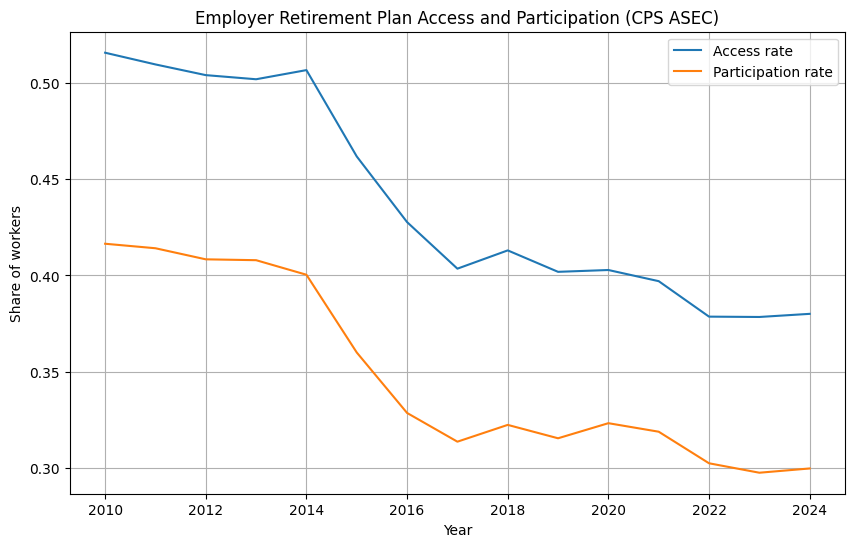

In [28]:
# Step 8: Plot the results
import matplotlib.pyplot as plt

# Here we set the figure size to make the plot larger and more readable.
plt.figure(figsize=(10,6))

# Here we fetch what we intend to plot from the results dataframe, and we label each line for the legend.
plt.plot(df_results["year"], df_results["access_rate"], label="Access rate")
plt.plot(df_results["year"], df_results["participation_unconditional"], label="Participation rate")

# Plot labels
plt.xlabel("Year")
plt.ylabel("Share of workers")
plt.title("Employer Retirement Plan Access and Participation (CPS ASEC)")
plt.legend()
plt.grid(True)

plt.show()

Now this is interesting: the access rate is about 51.6% in 2010 and that drops to about 38.0% in 2024. We see a large drop around 2015–2017, then stabilization. As far as why we might expect to see that (without making any causal claims) could be a shift toward contract/gig work, a decline of DB pensions, growth of small-firm employment, and potentially a compositional change in private sector. It could be all of these all at the same time, none of these, a mix in between, or for completely different reasons---we do not know and this could be where someone with a PhD in economics could come in and save the day. 

Well, time to get this done and put together a report!

## Step 9b — Save the Figure

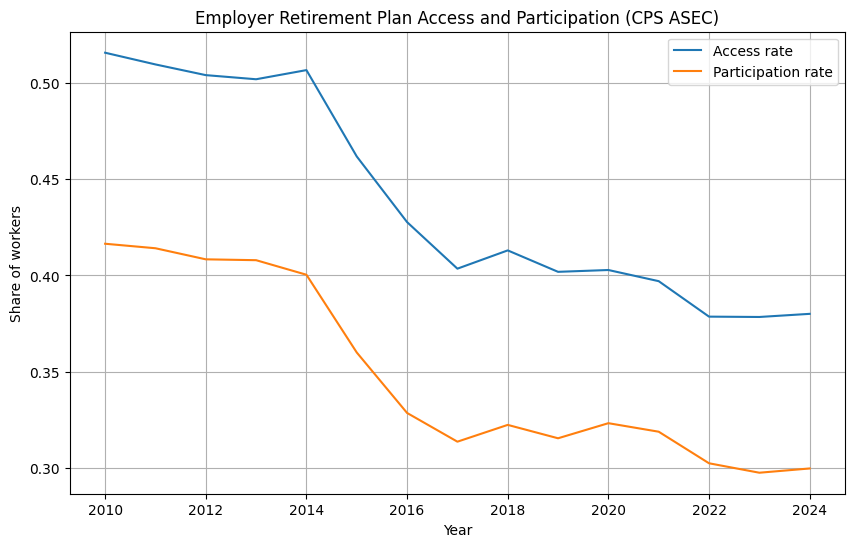

Figure saved to: ./output/figures/retirement_access_participation_timeseries.png


In [31]:
# Step 9b: Save the figure using project-defined paths

# We rely on FIGURES_DIR defined in project_paths.py so that
# the notebook remains fully reproducible across machines.

# Ensure the figures directory exists (safe even if it already exists)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Re-create the plot so the saved file matches the displayed output
plt.figure(figsize=(10,6))

# Plot the access rate time series
plt.plot(
    df_results["year"],
    df_results["access_rate"],
    label="Access rate"
)

# Plot the unconditional participation rate
plt.plot(
    df_results["year"],
    df_results["participation_unconditional"],
    label="Participation rate"
)

# Add labels and formatting for readability
plt.xlabel("Year")
plt.ylabel("Share of workers")
plt.title("Employer Retirement Plan Access and Participation (CPS ASEC)")
plt.legend()
plt.grid(True)

# Define the output filename
figure_file = FIGURES_DIR / "retirement_access_participation_timeseries.png"

# Save the figure with high resolution suitable for reports
plt.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight"
)

# Display the figure in the notebook
plt.show()

# Confirm save location
print(f"Figure saved to: {figure_file}")

## Step 9c — Save the tables from earlier

In [32]:
# Step 9c: Save the results table using project-defined paths

# Ensure the tables directory exists
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# Define the output file name
table_file = TABLES_DIR / "retirement_access_participation_timeseries.csv"

# Export the results dataframe to CSV
df_results.to_csv(
    table_file,
    index=False
)

# Confirm the save location
print(f"Table saved to: {table_file}")

Table saved to: ./output/tables/retirement_access_participation_timeseries.csv


## Step 10 — Compute Standard Errors and Confidence Intervals

Thus far, we have computed weighted point estimates of:

- retirement plan access
- unconditional participation
- conditional participation

using CPS ASEC weights.

However, point estimates alone do not convey statistical uncertainty. To quantify the precision of these estimates, we compute **weighted standard errors** and **95% confidence intervals** for each annual estimate.

For a weighted mean $\hat{\mu}$, we estimate the variance using the weighted sample variance formula:

$$
Var(\hat{\mu}) = \frac{\sum w_i (x_i - \hat{\mu})^2}{(\sum w_i)^2}
$$

The **standard error** is the square root of this variance.

We then construct **95% confidence intervals** using:

$$
\hat{\mu} \pm 1.96 \times SE
$$

These intervals provide a useful measure of sampling uncertainty around the CPS estimates.

In [33]:
# Step 10: Compute weighted standard errors and confidence intervals

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def weighted_mean(x, w):
    """
    Compute the weighted mean of a variable.

    Parameters
    ----------
    x : pandas Series
        Variable of interest
    w : pandas Series
        Sampling weights

    Returns
    -------
    float
        Weighted mean
    """
    return (x * w).sum() / w.sum()


def weighted_se(x, w):
    """
    Compute the standard error of a weighted mean.

    This uses a simple weighted variance estimator suitable
    for descriptive statistics in CPS-style microdata.

    Parameters
    ----------
    x : pandas Series
        Variable of interest
    w : pandas Series
        Sampling weights

    Returns
    -------
    float
        Standard error of the weighted mean
    """

    mu = weighted_mean(x, w)

    # Weighted variance of the estimator
    var = (w * (x - mu) ** 2).sum() / (w.sum() ** 2)

    return np.sqrt(var)


# ------------------------------------------------------------
# Compute yearly estimates with standard errors
# ------------------------------------------------------------

results_se = []

for year, g in df_worker.groupby("YEAR"):

    w = g["ASECWT"]

    # ---- Access rate ----
    access_rate = weighted_mean(g["access"], w)
    access_se = weighted_se(g["access"], w)

    # ---- Unconditional participation ----
    part_uncond = weighted_mean(g["participate_unconditional"], w)
    part_uncond_se = weighted_se(g["participate_unconditional"], w)

    # ---- Conditional participation (only workers with access) ----
    g_access = g[g["access"] == 1]

    part_cond = weighted_mean(
        g_access["participate_conditional"],
        g_access["ASECWT"]
    )

    part_cond_se = weighted_se(
        g_access["participate_conditional"],
        g_access["ASECWT"]
    )

    results_se.append({
        "year": year,

        "access_rate": access_rate,
        "access_se": access_se,

        "participation_unconditional": part_uncond,
        "participation_unconditional_se": part_uncond_se,

        "participation_conditional": part_cond,
        "participation_conditional_se": part_cond_se,

        "n_obs": len(g)
    })


# Convert to DataFrame
df_results_se = pd.DataFrame(results_se).sort_values("year")


# ------------------------------------------------------------
# Compute 95% confidence intervals
# ------------------------------------------------------------

z = 1.96

df_results_se["access_ci_lower"] = df_results_se["access_rate"] - z * df_results_se["access_se"]
df_results_se["access_ci_upper"] = df_results_se["access_rate"] + z * df_results_se["access_se"]

df_results_se["participation_ci_lower"] = (
    df_results_se["participation_unconditional"]
    - z * df_results_se["participation_unconditional_se"]
)

df_results_se["participation_ci_upper"] = (
    df_results_se["participation_unconditional"]
    + z * df_results_se["participation_unconditional_se"]
)


# Inspect results
df_results_se.head()

,year,access_rate,access_se,participation_unconditional,participation_unconditional_se,participation_conditional,participation_conditional_se,n_obs,access_ci_lower,access_ci_upper,participation_ci_lower,participation_ci_upper
0,2010,0.515733,0.000051,0.416458,0.000051,0.807507,0.000057,62712,0.515633,0.515833,0.416359,0.416557
1,2011,0.509647,0.000051,0.414117,0.000050,0.812556,0.000056,61968,0.509548,0.509747,0.414019,0.414215
2,2012,0.504088,0.000050,0.408361,0.000049,0.810098,0.000056,61862,0.503990,0.504186,0.408264,0.408457
3,2013,0.501945,0.000050,0.407910,0.000049,0.812660,0.000055,62212,0.501848,0.502042,0.407814,0.408007
4,2014,0.506698,0.000035,0.400347,0.000034,0.790110,0.000040,61883,0.506630,0.506766,0.400280,0.400414


We save these results as a table...

In [34]:
# Save the table with standard errors for reference in the write-up

TABLES_DIR.mkdir(parents=True, exist_ok=True)

se_table_file = TABLES_DIR / "retirement_access_participation_with_se.csv"

df_results_se.to_csv(
    se_table_file,
    index=False
)

print(f"Standard error table saved to: {se_table_file}")

Standard error table saved to: ./output/tables/retirement_access_participation_with_se.csv


## Step 10b — Plot yearly estimates with 95% confidence bands

I now visualize the weighted annual estimates together with their 95% confidence intervals.

This figure reports:
- the annual retirement plan access rate
- the annual unconditional participation rate

both measured among private-sector wage-and-salary workers ages 20–64 in the CPS ASEC.

The shaded regions represent 95% confidence intervals constructed from the weighted standard errors computed in the previous step. Including these intervals makes the figure more transparent about sampling uncertainty and better aligned with professional policy-research presentation standards.

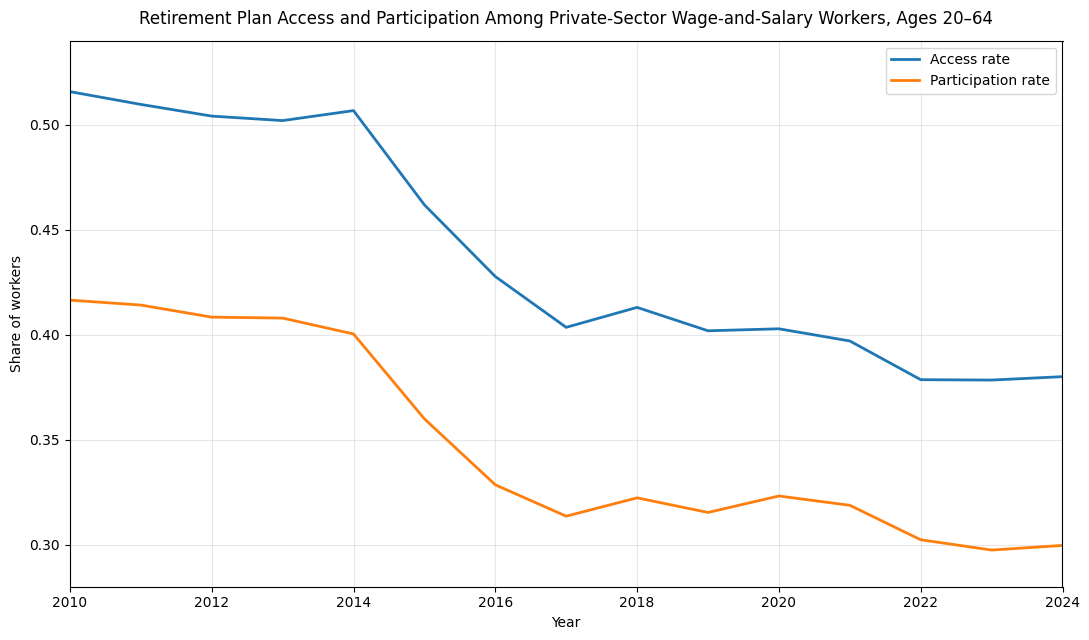

Figure saved to: ./output/figures/retirement_access_participation_confidence_bands.png


In [35]:
# Step 10b: Plot weighted annual estimates with 95% confidence bands

# ------------------------------------------------------------
# Create a Brookings-style line plot with confidence bands
# ------------------------------------------------------------

# Make sure the output folder exists before saving files.
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Create the figure.
fig, ax = plt.subplots(figsize=(11, 6.5))

# ------------------------------------------------------------
# Plot the access-rate series
# ------------------------------------------------------------
ax.plot(
    df_results_se["year"],
    df_results_se["access_rate"],
    linewidth=2,
    label="Access rate"
)

ax.fill_between(
    df_results_se["year"],
    df_results_se["access_ci_lower"],
    df_results_se["access_ci_upper"],
    alpha=0.18
)

# ------------------------------------------------------------
# Plot the unconditional participation-rate series
# ------------------------------------------------------------
ax.plot(
    df_results_se["year"],
    df_results_se["participation_unconditional"],
    linewidth=2,
    label="Participation rate"
)

ax.fill_between(
    df_results_se["year"],
    df_results_se["participation_ci_lower"],
    df_results_se["participation_ci_upper"],
    alpha=0.18
)

# ------------------------------------------------------------
# Format the figure for readability
# ------------------------------------------------------------
ax.set_title(
    "Retirement Plan Access and Participation Among Private-Sector Wage-and-Salary Workers, Ages 20–64",
    pad=12
)

ax.set_xlabel("Year")
ax.set_ylabel("Share of workers")

ax.set_xlim(df_results_se["year"].min(), df_results_se["year"].max())
ax.set_ylim(0.28, 0.54)

ax.grid(True, alpha=0.3)
ax.legend(frameon=True)

# Tight layout helps prevent label/title clipping.
fig.tight_layout()

# ------------------------------------------------------------
# Save the figure to the project figures folder
# ------------------------------------------------------------
figure_file = FIGURES_DIR / "retirement_access_participation_confidence_bands.png"
fig.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight"
)

# Show the figure in the notebook and confirm where it was saved.
plt.show()
print(f"Figure saved to: {figure_file}")

### Note on confidence intervals

I computed weighted standard errors and 95% confidence intervals for the annual estimates. In the plotted figure, the confidence bands are visually negligible because the annual CPS ASEC samples are large and the resulting confidence intervals are very narrow. For presentation clarity, I retain the confidence intervals in the accompanying results table and use a cleaner line figure in the main write-up.

## Step 10c - rounded presentation table

In [36]:
# Step 10c: Save a rounded presentation table for the write-up

# ------------------------------------------------------------
# Create a cleaner table for presentation purposes
# ------------------------------------------------------------

TABLES_DIR.mkdir(parents=True, exist_ok=True)

df_results_present = df_results_se.copy()

# Round columns that will likely appear in the memo/write-up.
rate_cols = [
    "access_rate",
    "access_se",
    "access_ci_lower",
    "access_ci_upper",
    "participation_unconditional",
    "participation_unconditional_se",
    "participation_ci_lower",
    "participation_ci_upper",
    "participation_conditional",
    "participation_conditional_se",
]

for col in rate_cols:
    if col in df_results_present.columns:
        df_results_present[col] = df_results_present[col].round(4)

presentation_table_file = TABLES_DIR / "retirement_access_participation_with_se_rounded.csv"
df_results_present.to_csv(presentation_table_file, index=False)

print(f"Rounded results table saved to: {presentation_table_file}")

Rounded results table saved to: ./output/tables/retirement_access_participation_with_se_rounded.csv


## Step 10d: Create the final presentation figure for the write-up

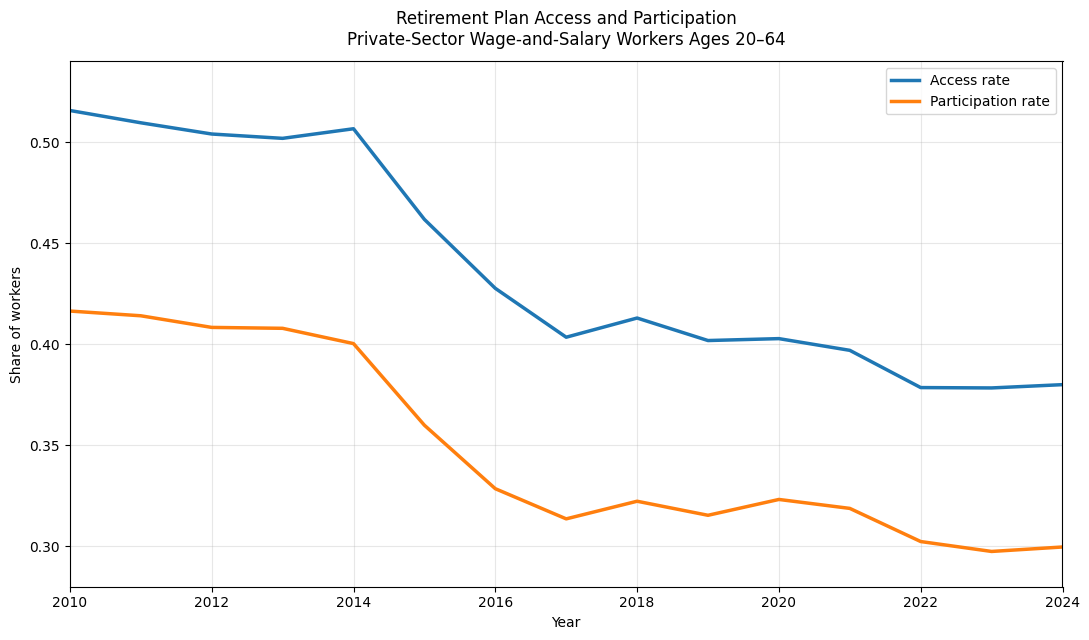

Final figure saved to: ./output/figures/retirement_access_participation_main_figure.png


In [37]:
# Step 10d: Create the final presentation figure for the write-up
#
# This version removes confidence bands because they are visually negligible
# at the current plotting scale. The supporting table still reports standard
# errors and confidence intervals for transparency.

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(11, 6.5))

# Plot annual access rate
ax.plot(
    df_results_se["year"],
    df_results_se["access_rate"],
    linewidth=2.5,
    label="Access rate"
)

# Plot annual unconditional participation rate
ax.plot(
    df_results_se["year"],
    df_results_se["participation_unconditional"],
    linewidth=2.5,
    label="Participation rate"
)

# Titles and labels
ax.set_title(
    "Retirement Plan Access and Participation\nPrivate-Sector Wage-and-Salary Workers Ages 20–64",
    pad=12
)
ax.set_xlabel("Year")
ax.set_ylabel("Share of workers")

# Axis formatting
ax.set_xlim(df_results_se["year"].min(), df_results_se["year"].max())
ax.set_ylim(0.28, 0.54)

# Grid and legend
ax.grid(True, alpha=0.3)
ax.legend(frameon=True)

# Tight layout improves spacing
fig.tight_layout()

# Save the final publication-style figure
final_figure_file = FIGURES_DIR / "retirement_access_participation_main_figure.png"
fig.savefig(
    final_figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
print(f"Final figure saved to: {final_figure_file}")

From here we are missing just the source note for the figure, but I am going to opt to add this in the latex write up since that affords greater control of how the final deliverable appears.

That note would look something like:

```latex
Source: Author’s calculations using the Current Population Survey Annual Social and Economic Supplement (CPS ASEC), 2010–2024.
Sample restricted to private-sector wage-and-salary workers ages 20–64.
Estimates weighted using CPS ASEC person weights.
```

## Step 11 — Produce formatted visual annual table

The assignment asks for a formatted table showing the retirement plan access rate and the sample size for each year, so let's do it! I also include the participation rate because it is central to the figure and analysis.

In [39]:
# Step 11: Create the final annual table requested in the prompt
TABLES_DIR.mkdir(parents=True, exist_ok=True)

df_final_table = df_results_se.loc[
    :,
    ["year", "access_rate", "participation_unconditional", "n_obs"]
].copy()

df_final_table = df_final_table.rename(
    columns={
        "year": "Year",
        "access_rate": "Access rate",
        "participation_unconditional": "Participation rate",
        "n_obs": "Sample size"
    }
)

# Round rates for presentation
df_final_table["Access rate"] = df_final_table["Access rate"].round(4)
df_final_table["Participation rate"] = df_final_table["Participation rate"].round(4)

final_table_file = TABLES_DIR / "final_annual_access_participation_table.csv"
df_final_table.to_csv(final_table_file, index=False)

df_final_table
print(f"Final annual table saved to: {final_table_file}")

Final annual table saved to: ./output/tables/final_annual_access_participation_table.csv
